# setting

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import OneHotEncoder
from collections import Counter

# for model evaluation
from sklearn.metrics import accuracy_score # モデル評価用(正答率)
from sklearn.metrics import log_loss # モデル評価用(logloss)     
from sklearn.metrics import roc_auc_score # モデル評価用(auc)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import warnings
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


In [2]:
warnings.simplefilter('ignore')

# data preparation

In [3]:
# load training data
train_data = pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')

In [4]:
# data imputation
# impute by CryoSleep
train_data.loc[(train_data['CryoSleep']==True) & (train_data['RoomService'].isnull()), 'RoomService'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['Spa'].isnull()), 'Spa'] = 0
train_data.loc[(train_data['CryoSleep']==True) & (train_data['VRDeck'].isnull()), 'VRDeck'] = 0

# impute by Age
train_data.loc[(train_data['Age']<13) & (train_data['RoomService'].isnull()), 'RoomService'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['Spa'].isnull()), 'Spa'] = 0
train_data.loc[(train_data['Age']<13) & (train_data['VRDeck'].isnull()), 'VRDeck'] = 0

In [5]:
# log transform
log_vars = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for log_var in log_vars:
    train_data[log_var + '_log'] = [np.log1p(x) for x in train_data[log_var]]

In [6]:
# create new features

# cabin
cabin_split = [str(x).split('/') if x!='nan' else x for x in train_data['Cabin']]
cabin_deck = [x[0] if len(x)>1 else x[0] for x in cabin_split]
cabin_num = [round(float(x[1])/10) if len(x)>1 else 999 for x in cabin_split]
cabin_side = [x[2] if len(x)>1 else x[0] for x in cabin_split]
cabin_df = pd.DataFrame(zip(cabin_deck, cabin_num, cabin_side)).rename(columns={0:'cabin_deck', 1:'cabin_num', 2:'cabin_side'})

# group or not, and number of group member
passengerId_split = [str(x).split('_') for x in train_data['PassengerId']]
passenger_groupId = [int(x[0]) for x in passengerId_split]
passengre_secondId = [x[1] for x in passengerId_split]
groupid_df = pd.DataFrame(zip(passenger_groupId, passengre_secondId)).rename(columns={0:'group_id', 1:'secondId'})
member_count = Counter(passenger_groupId)
member_count_df = pd.DataFrame.from_dict(member_count, orient = 'index').reset_index().rename(columns={'index':'group_id', 0:'member_num'})
member_count_df['group_bool'] = member_count_df.member_num>1
groupid_df = pd.merge(groupid_df, member_count_df, how='left')

# age is null
age_isnull_df = pd.DataFrame([int(b) for b in train_data['Age'].isnull()], columns=['age_isnull'])

# add to training data
train_data_add = pd.concat([train_data, cabin_df, groupid_df, age_isnull_df], axis = 1)

In [7]:
# create new features based on luxuary services
train_data_add['RoomService_bool'] = train_data_add['RoomService']>0
train_data_add['FoodCourt_bool'] = train_data_add['FoodCourt']>0
train_data_add['ShoppingMall_bool'] = train_data_add['ShoppingMall']>0
train_data_add['Spa_bool'] = train_data_add['Spa']>0
train_data_add['VRDeck_bool'] = train_data_add['VRDeck']>0
train_data_add['over12yrsold'] = train_data_add['Age']>12
train_data_add['num_serveces'] = np.array(train_data_add['RoomService_bool']).astype(int) + \
                                 np.array(train_data_add['FoodCourt_bool']).astype(int) + \
                                 np.array(train_data_add['ShoppingMall_bool']).astype(int) + \
                                 np.array(train_data_add['Spa_bool']).astype(int) + \
                                 np.array(train_data_add['VRDeck_bool']).astype(int)

# Data split for CV

In [8]:
test = np.array([0,1,2,3,4,5,6,7,8,9])
test[[True, False, True, False, False, False, False, False, False, False]]

array([0, 2])

In [9]:
# data split by stratified k-fold
# k=0 to 5 for training, k=0 for validation
skf = StratifiedKFold(n_splits=6, shuffle = True, random_state=0)

index_list = list(range(len(train_data_add)))
target_list = [int(b) for b in train_data_add['Transported']]

fold_list = np.array([0 for _ in range(len(train_data_add))])
n_fold = 0

for i in skf.split(index_list, target_list):
    #print(i[1].tolist())
    #print(fold_list[[i[1]]])
    fold_list[i[1]] = n_fold
    n_fold += 1

print(fold_list)
print(Counter(fold_list))
print(fold_list==0)
#print(target_list[fold_list==0])

# check target distribution
for i in range(6):
    print(Counter(np.array(target_list)[fold_list==i]))

[0 1 3 ... 5 3 2]
Counter({0: 1449, 1: 1449, 3: 1449, 2: 1449, 4: 1449, 5: 1448})
[ True False False ... False False False]
Counter({1: 729, 0: 720})
Counter({1: 730, 0: 719})
Counter({1: 730, 0: 719})
Counter({1: 730, 0: 719})
Counter({1: 730, 0: 719})
Counter({1: 729, 0: 719})


In [10]:
#Did not expect the data types in the following fields: HomePlanet, CryoSleep, Destination, VIP, cabin_deck, cabin_num, cabin_side, group_id
oe = OneHotEncoder(sparse = False,dtype = int)
train_data_dummy = pd.get_dummies(train_data_add[['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'CryoSleep', 'VIP', 'secondId']])
train_data_dummy

train_data_add = pd.concat([train_data_add.drop(['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'CryoSleep', 'VIP', 'PassengerId', 'Name', 'Cabin', 'secondId'], axis = 1),
                            train_data_dummy], axis=1)

#sl_np = oe.fit_transform(train_data_add[['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side']])
#pd.DataFrame(sl_np, columns=['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side'])

In [11]:
# create dataset for CV
train_datasets = []
num_dataset = 5
for i in range(num_dataset):
    print(i)
    X_train, y_train, X_test, y_test = train_data_add[(fold_list!=i) & (fold_list!=num_dataset)].drop('Transported', axis=1), \
                                       train_data_add[(fold_list!=i) & (fold_list!=num_dataset)]['Transported'], \
                                       train_data_add[(fold_list==i)].drop('Transported', axis=1), \
                                       train_data_add[(fold_list==i)]['Transported']
    train_datasets.append([X_train, y_train, X_test, y_test])

# validation data
X_validation, y_validation = train_data_add[fold_list==num_dataset].drop('Transported', axis=1) \
                                           , train_data_add[fold_list==num_dataset]['Transported']

0
1
2
3
4


In [12]:
X_validation.columns

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'RoomService_log', 'FoodCourt_log', 'ShoppingMall_log', 'Spa_log',
       'VRDeck_log', 'cabin_num', 'group_id', 'member_num', 'group_bool',
       'age_isnull', 'RoomService_bool', 'FoodCourt_bool', 'ShoppingMall_bool',
       'Spa_bool', 'VRDeck_bool', 'over12yrsold', 'num_serveces',
       'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_55 Cancri e', 'Destination_PSO J318.5-22',
       'Destination_TRAPPIST-1e', 'cabin_deck_A', 'cabin_deck_B',
       'cabin_deck_C', 'cabin_deck_D', 'cabin_deck_E', 'cabin_deck_F',
       'cabin_deck_G', 'cabin_deck_T', 'cabin_deck_nan', 'cabin_side_P',
       'cabin_side_S', 'cabin_side_nan', 'CryoSleep_False', 'CryoSleep_True',
       'VIP_False', 'VIP_True', 'secondId_01', 'secondId_02', 'secondId_03',
       'secondId_04', 'secondId_05', 'secondId_06', 'secondId_07',
       'secondId_08'],
      dtype='object')

# Learning

In [13]:
models = []

params = {
    'task': 'train',
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'verbose': 2,
}

for dataset in train_datasets:
    model = lgb.LGBMClassifier()
    
    train_data = lgb.Dataset(dataset[0], label=dataset[1])
    eval_data = lgb.Dataset(dataset[2], label=dataset[3], reference= train_data)
    
    model = lgb.train(params,
                      train_data,
                      valid_sets=eval_data,
                      num_boost_round=100,
                      verbose_eval=5)
    
    models.append(model)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2920, number of negative: 2876
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.766371
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.567628
[LightGBM] [Debug] init for col-wise cost 0.007473 seconds, init for row-wise cost 0.001549 seconds
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 3161
[LightGBM] [Info] Number of data points in the train set: 5796, number of used features: 51
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503796 -> initscore=0.015183
[LightGBM] [Info] Start training f

In [14]:
#y_pred_prob_list = model.predict(X_validation)
#p_list = [0.3,0.4, 0.5, 0.6]

#for p in p_list:
#    acc = accuracy_score(y_validation, y_pred_prob_list > p)
#    logloss =  log_loss(y_validation,y_pred_prob)
#    print(acc, logloss)

In [15]:
X_validation

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,...,VIP_False,VIP_True,secondId_01,secondId_02,secondId_03,secondId_04,secondId_05,secondId_06,secondId_07,secondId_08
4,16.0,303.0,70.0,151.0,565.0,2.0,5.717028,4.262680,5.023881,6.338594,...,1,0,1,0,0,0,0,0,0,0
21,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,1,0,0,0,0,0,0,0
23,29.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,0,0,1,0,0,0,0,0
27,21.0,980.0,2.0,69.0,0.0,0.0,6.888572,1.098612,4.248495,0.000000,...,1,0,1,0,0,0,0,0,0,0
28,62.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,20.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,0,1,0,0,0,0,0,0
8656,41.0,3.0,0.0,668.0,0.0,0.0,1.386294,0.000000,6.505784,0.000000,...,1,0,1,0,0,0,0,0,0,0
8679,20.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,0,1,0,0,0,0,0,0
8685,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,1,0,0,0,0,0,0,0


In [16]:
y_pred_list = np.zeros(len(y_validation))
y_pred_prob_list = np.zeros((len(y_validation),2))

for model in models:
    # prediction
    y_pred_prob = model.predict(X_validation)
    y_pred = y_pred_prob > 0.5
    #y_pred_prob = model.predict_proba(X_validation)
    y_pred_int = np.array([int(b) for b in y_pred])
    y_pred_list = y_pred_list + y_pred_int
    #y_pred_prob_list = y_pred_prob_list + np.array(y_pred_prob)
    
    # evaluation
    acc = accuracy_score(y_validation, y_pred)
    #logloss =  log_loss(y_validation,y_pred_prob)
    #auc = roc_auc_score(y_validation,y_pred_prob[:,1])
    
    print('Acc :', acc)
    #print('logloss :', logloss)
    #print('AUC :', auc) 
    print('\n')
    
# evaluation check
for n in range(10):
    acc_all = accuracy_score(y_validation, y_pred_list > n)
    print('num : ',n ,'Acc :', acc_all)
#logloss_all =  log_loss(y_validation,y_pred_prob_list/len(models))
#auc_all = roc_auc_score(y_validation,(y_pred_prob_list/len(models))[:,1])

#print('logloss :', logloss_all)
#print('AUC :', auc_all) 

Acc : 0.8142265193370166


Acc : 0.8162983425414365


Acc : 0.805939226519337


Acc : 0.8149171270718232


Acc : 0.8100828729281768


num :  0 Acc : 0.8149171270718232
num :  1 Acc : 0.8162983425414365
num :  2 Acc : 0.8156077348066298
num :  3 Acc : 0.81353591160221
num :  4 Acc : 0.8011049723756906
num :  5 Acc : 0.4965469613259669
num :  6 Acc : 0.4965469613259669
num :  7 Acc : 0.4965469613259669
num :  8 Acc : 0.4965469613259669
num :  9 Acc : 0.4965469613259669


In [17]:
importance_df = pd.DataFrame({'feature_name':X_validation.columns,'score':models[0].feature_importance()})
importance_df.sort_values('score', ascending=False)

,feature_name,score
12,group_id,332
11,cabin_num,322
0,Age,320
4,Spa,296
2,FoodCourt,286
5,VRDeck,284
1,RoomService,237
3,ShoppingMall,204
38,cabin_side_P,87
13,member_num,59


In [18]:
X_validation_with_pred = X_validation.copy(deep = True)
X_validation_with_pred['y_pred'] = y_pred_list
X_validation_with_pred['y_pred_label'] = y_pred_list > 2
X_validation_with_pred['y_test'] = y_validation
X_validation_with_pred['check'] = y_validation == (y_pred_list > 2)

In [19]:
X_validation_with_pred

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,RoomService_log,FoodCourt_log,ShoppingMall_log,Spa_log,...,secondId_03,secondId_04,secondId_05,secondId_06,secondId_07,secondId_08,y_pred,y_pred_label,y_test,check
4,16.0,303.0,70.0,151.0,565.0,2.0,5.717028,4.262680,5.023881,6.338594,...,0,0,0,0,0,0,0.0,False,True,False
21,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,4.0,True,False,False
23,29.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,1,0,0,0,0,0,5.0,True,False,False
27,21.0,980.0,2.0,69.0,0.0,0.0,6.888572,1.098612,4.248495,0.000000,...,0,0,0,0,0,0,0.0,False,False,True
28,62.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,5.0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,20.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,4.0,True,True,True
8656,41.0,3.0,0.0,668.0,0.0,0.0,1.386294,0.000000,6.505784,0.000000,...,0,0,0,0,0,0,5.0,True,True,True
8679,20.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,5.0,True,True,True
8685,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,5.0,True,True,True


In [20]:
X_validation_with_pred.to_csv('validation_datacheck.csv', index = False)

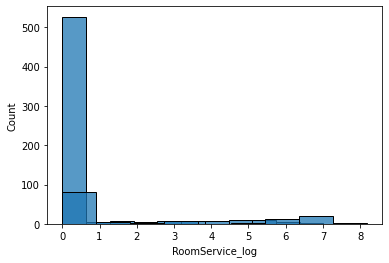

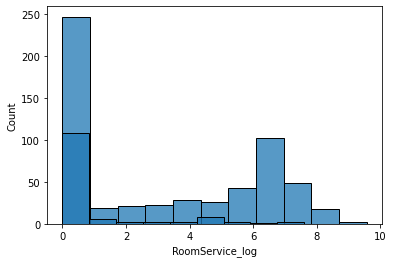

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(X_validation_with_pred[(X_validation_with_pred['check']==True) & (X_validation_with_pred['y_test']==True)]['RoomService_log'])
sns.histplot(X_validation_with_pred[(X_validation_with_pred['check']==False) & (X_validation_with_pred['y_test']==True)]['RoomService_log'])
plt.show()

sns.histplot(X_validation_with_pred[(X_validation_with_pred['check']==True) & (X_validation_with_pred['y_test']==False)]['RoomService_log'])
sns.histplot(X_validation_with_pred[(X_validation_with_pred['check']==False) & (X_validation_with_pred['y_test']==False)]['RoomService_log'])
plt.show()
#sns.histplot(X_validation_with_pred[(X_validation_with_pred['y_pred']==9)]['Age'])
#sns.histplot(X_validation_with_pred[(X_validation_with_pred['y_pred']<9) & (X_validation_with_pred['y_pred']>0)]['num_serveces'])

# prediction

In [22]:
# test data preparation

# load test data
test_data = pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')

# data imputation
# impute by CryoSleep
test_data.loc[(test_data['CryoSleep']==True) & (test_data['RoomService'].isnull()), 'RoomService'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['Spa'].isnull()), 'Spa'] = 0
test_data.loc[(test_data['CryoSleep']==True) & (test_data['VRDeck'].isnull()), 'VRDeck'] = 0

# impute by Age
test_data.loc[(test_data['Age']<13) & (test_data['RoomService'].isnull()), 'RoomService'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['FoodCourt'].isnull()), 'FoodCourt'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['ShoppingMall'].isnull()), 'ShoppingMall'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['Spa'].isnull()), 'Spa'] = 0
test_data.loc[(test_data['Age']<13) & (test_data['VRDeck'].isnull()), 'VRDeck'] = 0

# log transform
log_vars = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for log_var in log_vars:
    test_data[log_var + '_log'] = [np.log1p(x) for x in test_data[log_var]]
    
# create new features

# cabin
cabin_split = [str(x).split('/') if x!='nan' else x for x in test_data['Cabin']]
cabin_deck = [x[0] if len(x)>1 else x[0] for x in cabin_split]
cabin_num = [round(float(x[1])/10) if len(x)>1 else 999 for x in cabin_split]
cabin_side = [x[2] if len(x)>1 else x[0] for x in cabin_split]
cabin_df = pd.DataFrame(zip(cabin_deck, cabin_num, cabin_side)).rename(columns={0:'cabin_deck', 1:'cabin_num', 2:'cabin_side'})

# group or not, and number of group member
passengerId_split = [str(x).split('_') for x in test_data['PassengerId']]
passenger_groupId = [int(x[0]) for x in passengerId_split]
passengre_secondId = [x[1] for x in passengerId_split]
groupid_df = pd.DataFrame(zip(passenger_groupId, passengre_secondId)).rename(columns={0:'group_id', 1:'secondId'})
member_count = Counter(passenger_groupId)
member_count_df = pd.DataFrame.from_dict(member_count, orient = 'index').reset_index().rename(columns={'index':'group_id', 0:'member_num'})
member_count_df['group_bool'] = member_count_df.member_num>1
groupid_df = pd.merge(groupid_df, member_count_df, how='left')

# age is null
age_isnull_df = pd.DataFrame([int(b) for b in test_data['Age'].isnull()], columns=['age_isnull'])

# add to testing data
test_data_add = pd.concat([test_data, cabin_df, groupid_df, age_isnull_df], axis = 1)

# create new features based on luxuary services
test_data_add['RoomService_bool'] = test_data_add['RoomService']>0
test_data_add['FoodCourt_bool'] = test_data_add['FoodCourt']>0
test_data_add['ShoppingMall_bool'] = test_data_add['ShoppingMall']>0
test_data_add['Spa_bool'] = test_data_add['Spa']>0
test_data_add['VRDeck_bool'] = test_data_add['VRDeck']>0
test_data_add['over12yrsold'] = test_data_add['Age']>12
test_data_add['num_serveces'] = np.array(test_data_add['RoomService_bool']).astype(int) + \
                                np.array(test_data_add['FoodCourt_bool']).astype(int) + \
                                np.array(test_data_add['ShoppingMall_bool']).astype(int) + \
                                np.array(test_data_add['Spa_bool']).astype(int) + \
                                np.array(test_data_add['VRDeck_bool']).astype(int)

# one-hot encoding
oe = OneHotEncoder(sparse = False,dtype = int)
test_data_dummy = pd.get_dummies(test_data_add[['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'CryoSleep', 'VIP', 'secondId']])
test_data_dummy

test_data_add = pd.concat([test_data_add.drop(['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'CryoSleep', 'VIP', 'PassengerId', 'Name', 'Cabin', 'secondId'], axis = 1),
                            test_data_dummy], axis=1)

In [23]:
# prediction
y_pred_list = np.zeros(len(test_data_add))

for model in models:
    # prediction
    y_pred_prob = model.predict(test_data_add)
    y_pred = y_pred_prob > 0.5
    y_pred_int = np.array([int(b) for b in y_pred])
    y_pred_list = y_pred_list + y_pred_int
    
# label prediction
pred_label = y_pred_list > 2

In [24]:
# create submission data
submission_df = pd.DataFrame(zip(test_data['PassengerId'], pred_label),
                            columns = ['PassengerId', 'Transported'])
submission_df

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


In [25]:
# output to csv
submission_df.to_csv('submission.csv', index = False)